In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings('ignore')
import os

In [51]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.activations import relu , softmax
from sklearn.metrics import accuracy_score, confusion_matrix

In [52]:
training_data_path = '/content/drive/MyDrive/Deep_Learning/CNN/Multi_label/training_data'
test_data_path = '/content/drive/MyDrive/Deep_Learning/CNN/Multi_label/testing_data'
validation_data_path = '/content/drive/MyDrive/Deep_Learning/CNN/Multi_label/validation_data'

In [53]:
os.listdir(training_data_path)

['ZEBRA LONG WING',
 'YELLOW SWALLOW TAIL',
 'VICEROY',
 'WOOD SATYR',
 'SLEEPY ORANGE',
 'SOOTYWING',
 'TWO BARRED FLASHER',
 'ULYSES',
 'TROPICAL LEAFWING',
 'SOUTHERN DOGFACE',
 'STRAITED QUEEN',
 'SCARCE SWALLOW',
 'SILVER SPOT SKIPPER',
 'RED SPOTTED PURPLE',
 'RED POSTMAN',
 'RED ADMIRAL',
 'RED CRACKER',
 'PURPLISH COPPER',
 'QUESTION MARK',
 'PURPLE HAIRSTREAK',
 'POPINJAY',
 'PEACOCK',
 'PINE WHITE',
 'PIPEVINE SWALLOW',
 'ORANGE TIP',
 'ORCHARD SWALLOW',
 'ORANGE OAKLEAF',
 'PAPER KITE',
 'PAINTED LADY',
 'MOURNING CLOAK',
 'MONARCH',
 'METALMARK',
 'MILBERTS TORTOISESHELL',
 'MESTRA',
 'MANGROVE SKIPPER',
 'LARGE MARBLE',
 'INDRA SWALLOW',
 'JULIA',
 'GREY HAIRSTREAK',
 'IPHICLUS SISTER',
 'MALACHITE',
 'GREAT EGGFLY',
 'GREEN CELLED CATTLEHEART',
 'GREAT JAY',
 'GOLD BANDED',
 'CRIMSON PATCH',
 'DANAID EGGFLY',
 'ELBOWED PIERROT',
 'EASTERN COMA',
 'EASTERN PINE ELFIN',
 'EASTERN DAPPLE WHITE',
 'CRECENT',
 'COMMON WOOD-NYMPH',
 'COPPER TAIL',
 'CLOUDED SULPHUR',
 'CHESTNUT

In [54]:
os.listdir(test_data_path)

['YELLOW SWALLOW TAIL',
 'WOOD SATYR',
 'ZEBRA LONG WING',
 'VICEROY',
 'ULYSES',
 'RED POSTMAN',
 'STRAITED QUEEN',
 'TROPICAL LEAFWING',
 'TWO BARRED FLASHER',
 'SOOTYWING',
 'SLEEPY ORANGE',
 'RED SPOTTED PURPLE',
 'SOUTHERN DOGFACE',
 'SILVER SPOT SKIPPER',
 'SCARCE SWALLOW',
 'RED ADMIRAL',
 'RED CRACKER',
 'QUESTION MARK',
 'POPINJAY',
 'PURPLISH COPPER',
 'PINE WHITE',
 'PURPLE HAIRSTREAK',
 'PIPEVINE SWALLOW',
 'PAPER KITE',
 'PEACOCK',
 'MOURNING CLOAK',
 'PAINTED LADY',
 'MONARCH',
 'ORANGE TIP',
 'MILBERTS TORTOISESHELL',
 'ORANGE OAKLEAF',
 'ORCHARD SWALLOW',
 'MESTRA',
 'METALMARK',
 'MANGROVE SKIPPER',
 'GREY HAIRSTREAK',
 'LARGE MARBLE',
 'JULIA',
 'IPHICLUS SISTER',
 'MALACHITE',
 'ELBOWED PIERROT',
 'GREAT JAY',
 'INDRA SWALLOW',
 'GREEN CELLED CATTLEHEART',
 'GOLD BANDED',
 'EASTERN DAPPLE WHITE',
 'EASTERN COMA',
 'EASTERN PINE ELFIN',
 'CRECENT',
 'CLOUDED SULPHUR',
 'DANAID EGGFLY',
 'CRIMSON PATCH',
 'COPPER TAIL',
 'COMMON BANDED AWL',
 'COMMON WOOD-NYMPH',
 'CLO

In [55]:
os.listdir(validation_data_path)

['CRECENT',
 'COPPER TAIL',
 'CLOUDED SULPHUR',
 'EASTERN COMA',
 'CRIMSON PATCH',
 'COMMON WOOD-NYMPH',
 'GOLD BANDED',
 'GREAT EGGFLY',
 'DANAID EGGFLY',
 'ELBOWED PIERROT',
 'EASTERN DAPPLE WHITE',
 'GREEN CELLED CATTLEHEART',
 'EASTERN PINE ELFIN',
 'GREAT JAY',
 'ZEBRA LONG WING',
 'YELLOW SWALLOW TAIL',
 'TWO BARRED FLASHER',
 'ULYSES',
 'WOOD SATYR',
 'VICEROY',
 'TROPICAL LEAFWING',
 'SOUTHERN DOGFACE',
 'STRAITED QUEEN',
 'SOOTYWING',
 'SLEEPY ORANGE',
 'SCARCE SWALLOW',
 'SILVER SPOT SKIPPER',
 'RED SPOTTED PURPLE',
 'QUESTION MARK',
 'RED POSTMAN',
 'RED ADMIRAL',
 'RED CRACKER',
 'PURPLISH COPPER',
 'PURPLE HAIRSTREAK',
 'POPINJAY',
 'PIPEVINE SWALLOW',
 'PINE WHITE',
 'ORANGE OAKLEAF',
 'ORCHARD SWALLOW',
 'PAPER KITE',
 'MOURNING CLOAK',
 'PAINTED LADY',
 'ORANGE TIP',
 'PEACOCK',
 'MONARCH',
 'MILBERTS TORTOISESHELL',
 'METALMARK',
 'MESTRA',
 'JULIA',
 'INDRA SWALLOW',
 'IPHICLUS SISTER',
 'MANGROVE SKIPPER',
 'MALACHITE',
 'LARGE MARBLE',
 'GREY HAIRSTREAK',
 'COMMON B

In [56]:
os.listdir(training_data_path+'/ADONIS')


['Image_666.jpg',
 'Image_348.jpg',
 'Image_461.jpg',
 'Image_2488.jpg',
 'Image_2584.jpg',
 'Image_848.jpg',
 'Image_774.jpg',
 'Image_796.jpg',
 'Image_79.jpg',
 'Image_2655.jpg',
 'Image_452.jpg',
 'Image_555.jpg',
 'Image_2520.jpg',
 'Image_280.jpg',
 'Image_2360.jpg',
 'Image_2401.jpg',
 'Image_1565.jpg',
 'Image_1858.jpg',
 'Image_2203.jpg',
 'Image_2409.jpg',
 'Image_2101.jpg',
 'Image_1087.jpg',
 'Image_1937.jpg',
 'Image_1772.jpg',
 'Image_2275.jpg',
 'Image_2.jpg',
 'Image_1927.jpg',
 'Image_1131.jpg',
 'Image_1849.jpg',
 'Image_1712.jpg']

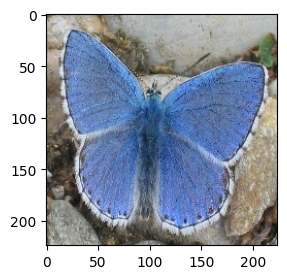

In [57]:
# showing 1 image
plt.figure(figsize=(5,3))
image = plt.imread(training_data_path+'/ADONIS/Image_1712.jpg')
plt.imshow(image)

In [58]:
train_formats = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   horizontal_flip=True,
                                   zoom_range=0.2)

val_formats = ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)

test_format = ImageDataGenerator(rescale=1./255)

In [59]:
print(train_formats)

In [60]:
train_data = train_formats.flow_from_directory(training_data_path,
                                               target_size = (256,256),
                                               class_mode='categorical',
                                               batch_size=16)

val_data = val_formats.flow_from_directory(validation_data_path,
                                           target_size=(256,256),
                                           class_mode='categorical',
                                           batch_size=16)

test_data = test_format.flow_from_directory(test_data_path,
                                            target_size=(256,256),
                                            class_mode='categorical',
                                            batch_size=16)

Found 2284 images belonging to 74 classes.
Found 608 images belonging to 74 classes.
Found 896 images belonging to 74 classes.


In [61]:
#Architecture
model = Sequential(name='Butterfly')
#layer1
model.add(Conv2D(128,
                 kernel_size=(3,3),
                 padding='same',
                 strides=(1,1),
                 input_shape=(256,256,3),
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))


#layer2
model.add(Conv2D(64,
                 kernel_size=(3,3),
                 strides=(1,1),
                 padding='same',
                 activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

#layer3
model.add(Conv2D(32,
                 kernel_size=(3,3),
                 strides=(1,1),
                 activation='relu',
                 padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

#layer4
model.add(Conv2D(16,
                 kernel_size=(3,3),
                 strides=(1,1),
                 activation='relu',
                 padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

#Flatten layer
model.add(Flatten())

#ANN
model.add(Dense(32,activation='relu'))#HL1
model.add(Dense(16,activation='relu'))#HL2

#output layer
model.add(Dense(74,activation='softmax'))



In [62]:
model.summary()

Model: "Butterfly"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 74)             │         1,258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,354 (911.54 KB)

 Trainable params: 233,354 (911.54 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(optimizer='adam',
              metrics=['accuracy'],
              loss='categorical_crossentropy')

In [64]:
from tensorflow.keras.callbacks import (ModelCheckpoint,
                                        EarlyStopping,
                                        ReduceLROnPlateau
                                        )

#ModelCheckpoint – save best model
# 2️⃣ EarlyStopping – stop overfitting
# 3️⃣ ReduceLROnPlateau – adjust learning rate

In [65]:
callbacks= [
    ModelCheckpoint(
        filepath = 'best_model.h5',
        monitor='val_loss',
        save_best_only=True
    ),

    EarlyStopping(
        monitor = 'val_loss',
        patience=5,
        restore_best_weights = True

    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6


    )
]

In [68]:
model.fit(
          train_data,
          epochs=50,
          validation_data=val_data,
          callbacks=callbacks
          )

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.1470 - loss: 3.2088

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 404ms/step - accuracy: 0.1470 - loss: 3.2088 - val_accuracy: 0.1217 - val_loss: 3.3668 - learning_rate: 0.0010
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.1605 - loss: 3.1180

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 404ms/step - accuracy: 0.1605 - loss: 3.1180 - val_accuracy: 0.1135 - val_loss: 3.3293 - learning_rate: 0.0010
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.1717 - loss: 3.0133

143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 415ms/step - accuracy: 0.1717 - loss: 3.0134 - val_accuracy: 0.1612 - val_loss: 3.2848 - learning_rate: 0.0010
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.1832 - loss: 2.9860

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 405ms/step - accuracy: 0.1832 - loss: 2.9860 - val_accuracy: 0.1826 - val_loss: 3.1760 - learning_rate: 0.0010
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.2055 - loss: 2.8769

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 405ms/step - accuracy: 0.2054 - loss: 2.8769 - val_accuracy: 0.1891 - val_loss: 3.1318 - learning_rate: 0.0010
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 406ms/step - accuracy: 0.2328 - loss: 2.7450 - val_accuracy: 0.1743 - val_loss: 3.1393 - learning_rate: 0.0010
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 394ms/step - accuracy: 0.2142 - loss: 2.7459 - val_accuracy: 0.1743 - val_loss: 3.1677 - learning_rate: 0.0010
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.2293 - loss: 2.6414

143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 395ms/step - accuracy: 0.2295 - loss: 2.6410 - val_accuracy: 0.2204 - val_loss: 3.0149 - learning_rate: 2.0000e-04
Epoch 9/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.2566 - loss: 2.5655

143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 398ms/step - accuracy: 0.2566 - loss: 2.5654 - val_accuracy: 0.2072 - val_loss: 2.9473 - learning_rate: 2.0000e-04
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 399ms/step - accuracy: 0.2812 - loss: 2.4952 - val_accuracy: 0.2039 - val_loss: 2.9739 - learning_rate: 2.0000e-04
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 398ms/step - accuracy: 0.2592 - loss: 2.5218 - val_accuracy: 0.2352 - val_loss: 2.9568 - learning_rate: 2.0000e-04
Epoch 12/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.2759 - loss: 2.4660

143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 396ms/step - accuracy: 0.2759 - loss: 2.4660 - val_accuracy: 0.2336 - val_loss: 2.9114 - learning_rate: 4.0000e-05
Epoch 13/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 395ms/step - accuracy: 0.3029 - loss: 2.3933 - val_accuracy: 0.2188 - val_loss: 2.9823 - learning_rate: 4.0000e-05
Epoch 14/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 395ms/step - accuracy: 0.2805 - loss: 2.4470 - val_accuracy: 0.2155 - val_loss: 2.9130 - learning_rate: 4.0000e-05
Epoch 15/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 394ms/step - accuracy: 0.2887 - loss: 2.4249 - val_accuracy: 0.2681 - val_loss: 2.9360 - learning_rate: 8.0000e-06
Epoch 16/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 401ms/step - accuracy: 0.3046 - loss: 2.3714 - val_accuracy: 0.2385 - val_loss: 2.9411 - learning_rate: 8.0000e-06
Epoch 17/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 57s 401ms/step - accuracy: 0.2911 - loss: 2.3863 - val_accuracy: 0.2138 - val_loss: 2.9599 - learning_rate: 1.6000e-06


In [69]:
y_prob = model.predict(test_data)
y_pred = np.argmax(y_prob,axis=1)

y_true = test_data.classes

label_map = test_data.class_indices
label_names = {v:k for k,v in label_map.items()}

predicted_labels = [label_names[i] for i in y_pred]

56/56 ━━━━━━━━━━━━━━━━━━━━ 318s 6s/step


In [70]:
print(accuracy_score(y_true,y_pred))
print(confusion_matrix(y_true,y_pred))


0.013392857142857142
[[0 0 0 ... 0 0 0]
 [2 0 0 ... 0 1 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 1]
 [1 1 0 ... 0 0 0]]


In [71]:
import cv2

In [72]:
#testing from google image
def testing(path):

  image = cv2.imread(path)
  resized_image = cv2.resize(image,(256,256))
  scaled_image = resized_image/255.0
  final_image = np.expand_dims(scaled_image,axis=1)

  output = model.predict(final_image)

  print(output[0][0])

  predicted_index = np.argmax(output,axis=1)[0]

  label_map = {v:k for k,v in train_data.class_indices.items()}
  predicted_label = label_map[predicted_index]


  plt.imshow(image[:,:,::-1])
  plt.axis('off')
  plt.title(f"prediction:{predicted_label}")
  plt.show()

  print('predicted_class',predicted_label)




In [73]:
testing("/content/drive/MyDrive/Deep_Learning/CNN/Multi_label/butterfly.jpg")

ValueError: Exception encountered when calling MaxPooling2D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node Butterfly_1/max_pooling2d_13_1/MaxPool2d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 2, 2, 1], padding="VALID", strides=[1, 2, 2, 1]](Butterfly_1/conv2d_13_1/Relu)' with input shapes: [32,1,256,128].[0m

Arguments received by MaxPooling2D.call():
  • inputs=tf.Tensor(shape=(32, 1, 256, 128), dtype=float32)